In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import easyclimate as ecl
import matplotlib.pyplot as plt

c:\Users\norna\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.DataArray 'time' (time: 13008)> Size: 104kB
array(['1991-01-01T00:00:00', '1991-01-02T00:00:00', '1991-01-03T00:00:00',
       ..., '2026-08-13T00:00:00', '2026-08-14T00:00:00',
       '2026-08-15T00:00:00'], shape=(13008,), dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 104kB 1991-01-01 1991-01-02 ... 2026-08-15


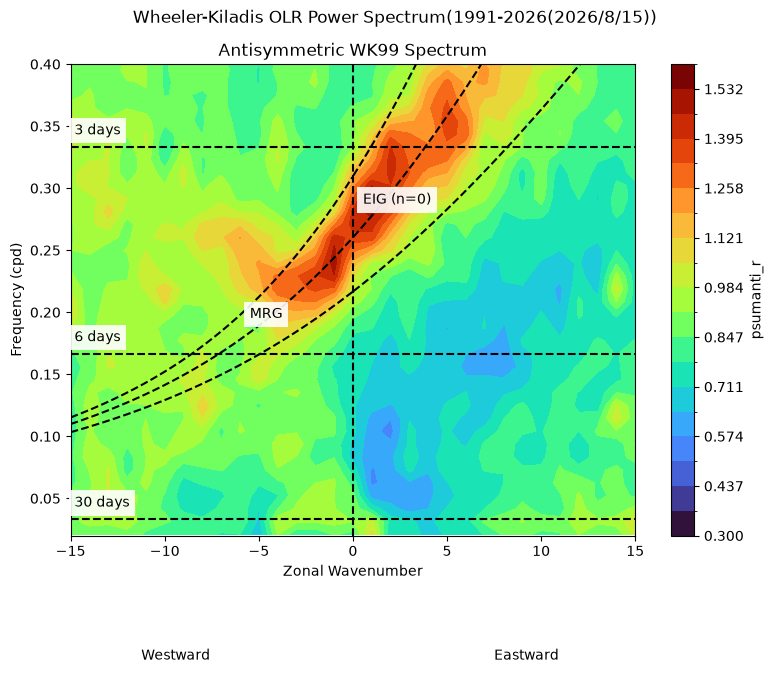

In [2]:

####Plotting WK99

#converting to usable data
ds=xr.open_dataset(r"C:\Users\norna\Downloads\olr.cbo-1deg.day.anom_2.nc", decode_times=False)
time_values=ds['time'].values
valid_mask=(time_values >= 0)&(time_values < 1e10) 
ds=ds.isel(time=valid_mask)
time_actual=pd.to_datetime(ds['time'].values,unit='h',origin='1800-01-01')
ds=ds.assign_coords(time=time_actual)
print(ds['olr']['time'])
data=ds['olr'].sel(time=slice('1991-01-01','2026-08-15')).sel(lat=slice(15,-15))
data=data.interpolate_na(dim="time", method="linear").ffill(dim="time").bfill(dim="time")


NT=data.shape[0]
SEG =96
SKIP =60
#how many days easyclimate will use internally
n_segs=(NT-SEG)//(SEG-SKIP)+1
NT_use=SEG+(n_segs-1)*(SEG-SKIP)
data=data.isel(time=slice(0,NT_use))


olr_cleaned=ecl.field.equatorial_wave.wk_spectra.remove_dominant_signals(data,1,96,60)
decomposed_data=ecl.field.equatorial_wave.wk_spectra.decompose_symasym(olr_cleaned,lat_dim="lat")
spectral_result=ecl.field.equatorial_wave.wk_spectra.calc_spectral_coefficients(decomposed_data,1,96,60)

fig,ax=plt.subplots(figsize=(8,7))
# Antisymmetric
spectral_result["psumanti_r"].plot.contourf(ax=ax,x="k",y="freq",cmap="turbo",levels=np.linspace(0.3, 1.6,20))
ecl.field.equatorial_wave.wk_spectra.draw_wk_anti_analysis(max_freq=0.4,max_wn=15,ax=ax,he=[12, 25, 50],meridional_modes=[1])
ax.set_title("Antisymmetric WK99 Spectrum")
ax.set_xlabel("Zonal Wavenumber")
ax.set_ylabel("Frequency (cpd)")


fig.suptitle("Wheeler-Kiladis OLR Power Spectrum(1991-2026(2026/8/15))")
plt.tight_layout()
plt.show()

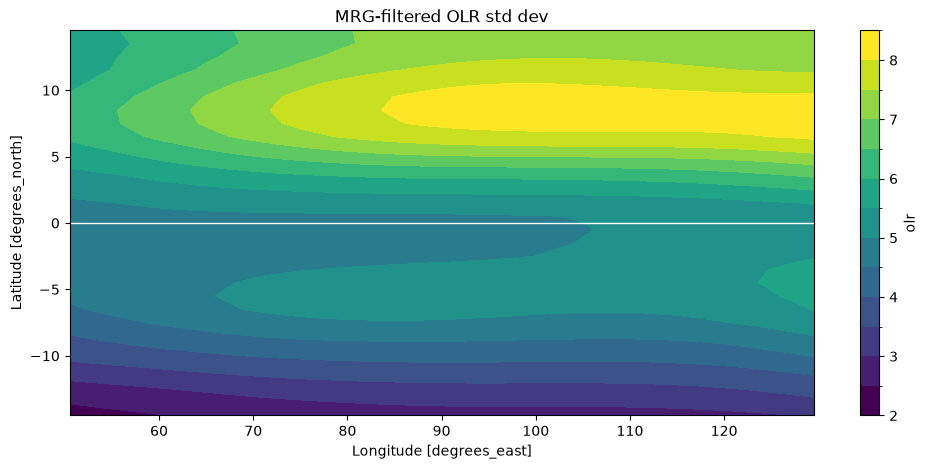

In [3]:
####OLR anomalies 
mrg_filtered=ecl.filter.kf_filter.kf_filter_mrg_wave(data,steps_per_day=1,tMin=3,tMax=9.6,kMin=-10,kMax=-2,hMin=10,hMax=100)


mrg_wide=mrg_filtered.sel(lon=slice(50,130)) #max 60-120
mrg_jjas_wide=mrg_wide.sel(time=mrg_wide.time.dt.month.isin([6,7,8,9]))

std_map=mrg_jjas_wide.std(dim='time')
fig,ax=plt.subplots(figsize=(12,5))
std_map.plot.contourf(ax=ax,cmap='viridis',levels=15)
ax.axhline(0,color='white',linewidth=1)
ax.set_title('MRG-filtered OLR standard deviation')
plt.show()

In [4]:
from scipy.signal import find_peaks

mrg_jjas_sorted = mrg_jjas_wide.sortby('lat')
domain=mrg_jjas_sorted.sel(lat=slice(-10,10),lon=slice(60,120))
mrg_index=domain.std(dim=['lat', 'lon'])

# 5. Normalize
mrg_index_std = (mrg_index - mrg_index.mean()) / mrg_index.std()


vals = mrg_index_std.values
times = mrg_index_std.time.values

# Use find_peaks directly on the positive RMS index
peaks_idx, props = find_peaks(
    vals,            
    height=2,      # 2 standard deviations
    distance=5,      # Minimum 5 days between events
    width=2         
)

events = pd.DataFrame({
    'peak_date': pd.to_datetime(times[peaks_idx]),
    'peak_amplitude': vals[peaks_idx]
}).sort_values('peak_date').reset_index(drop=True)

print(f"{len(events)} MRG events identified")
print(events)

30 MRG events identified
    peak_date  peak_amplitude
0  1994-08-24        3.079524
1  1994-09-13        3.159364
2  1998-08-11        2.386312
3  1999-07-27        3.070286
4  2003-07-13        2.153186
5  2005-07-15        2.399992
6  2006-06-03        2.373621
7  2008-08-11        3.239295
8  2009-06-16        2.202217
9  2009-07-21        2.858653
10 2010-06-21        3.249653
11 2010-07-31        3.174668
12 2010-08-28        3.885840
13 2012-06-27        2.116487
14 2012-07-23        2.006476
15 2013-06-27        2.156489
16 2013-08-13        2.629514
17 2014-07-02        2.501682
18 2015-07-20        2.405841
19 2015-08-15        2.467640
20 2015-09-21        2.317639
21 2017-09-17        2.683996
22 2018-09-06        2.851803
23 2019-09-11        2.457917
24 2020-06-15        3.259550
25 2020-08-23        3.723678
26 2020-09-25        2.002668
27 2022-07-11        2.133308
28 2024-06-10        2.747415
29 2025-08-23        2.827181


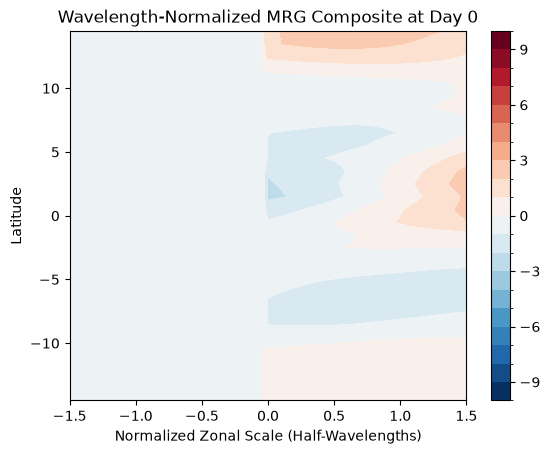

In [ ]:
# ============================================================
# Step 1: Estimate half-wavelength L for each MRG event at Day 0
# ============================================================
# olr_filt: xarray DataArray, WK-filtered MRG-band OLR anomaly, dims (time, lat, lon)
# events: list of dicts with 'event_id', 'day0_time', 'day0_lon' (from your Day-0 detection)

ref_lat_band = olr_filt.sel(lat=slice(-15, 15))       # your reference MRG latitude band
olr_zonal = ref_lat_band.mean(dim='lat')               # meridional mean -> (time, lon)

search_window_deg = 50   # generous window around lon0 to find the flanking troughs
                          # adjust based on expected MRG wavelength (roughly 40-70 deg is typical)

for ev in events:
    profile = olr_zonal.sel(time=ev['day0_time'], method='nearest')
    lon0 = ev['day0_lon']

    win = profile.sel(lon=slice(lon0 - search_window_deg, lon0 + search_window_deg))
    lons = win.lon.values
    vals = win.values

    center_idx = np.argmin(np.abs(lons - lon0))

    # find the next local minimum (trough) to the west
    i = center_idx - 1
    while i > 0 and not (vals[i] < vals[i-1] and vals[i] < vals[i+1]):
        i -= 1
    lon_west_trough = lons[i]

    # find the next local minimum (trough) to the east
    j = center_idx + 1
    while j < len(vals) - 1 and not (vals[j] < vals[j-1] and vals[j] < vals[j+1]):
        j += 1
    lon_east_trough = lons[j]

    wavelength_deg = lon_east_trough - lon_west_trough   # trough-to-trough = full wavelength
    ev['L_deg'] = 0.5 * wavelength_deg                    # half-wavelength

    if ev['L_deg'] <= 0 or ev['L_deg'] > search_window_deg:
        print(f"WARNING: suspicious L for event {ev['event_id']}, check manually")

# quick sanity check on the spread before deciding whether normalization is worth it
L_values = np.array([ev['L_deg'] for ev in events])
print(f"L (deg lon): mean={L_values.mean():.1f}, std={L_values.std():.1f}, "
      f"CV={L_values.std()/L_values.mean():.2f}, range=({L_values.min():.1f}, {L_values.max():.1f})")

# ============================================================
# Step 2: Build the composite on a normalized zonal axis
# ============================================================
norm_grid = np.linspace(-1.5, 1.5, 61)   # target axis, in units of L (i.e., -1.5L to +1.5L)
lag_days = np.arange(-10, 11)             # your lead-lag window

composite_accum = []

for ev in events:
    if ev['L_deg'] <= 0:
        continue   # skip flagged events

    lon0 = ev['day0_lon']
    L_deg = ev['L_deg']

    event_by_lag = []
    for lag in lag_days:
        t = ev['day0_time'] + np.timedelta64(int(lag), 'D')
        field_slice = your_budget_term.sel(time=t, method='nearest')   # e.g. (lat, lon) or (lat, lon, level)

        rel_lon_norm = (field_slice.lon - lon0) / L_deg                # rescale by this event's L
        field_relabeled = field_slice.assign_coords(lon=rel_lon_norm)
        field_interp = field_relabeled.interp(lon=norm_grid)           # onto common normalized grid

        event_by_lag.append(field_interp)

    event_da = xr.concat(event_by_lag, dim='lag').assign_coords(lag=lag_days)
    composite_accum.append(event_da)

all_events_da = xr.concat(composite_accum, dim='event')
composite_mean = all_events_da.mean(dim='event')
composite_std = all_events_da.std(dim='event')     # event-to-event spread — report this
n_events = all_events_da.sizes['event']

# ============================================================
# Step 3 (recommended): build the un-normalized version too, for comparison
# ============================================================
# Repeat Step 2 but skip the division by L_deg (use raw rel_lon in physical distance,
# e.g. km via rel_lon * 111 * cos(lat0), or plain degrees) and interpolate onto a
# common physical-distance grid instead of norm_grid. Compare the two composites
# side by side before deciding which goes in the final analysis.